
# 🏁 iRacing Telemetry → Coaching Pipeline (End-to-End)

This notebook builds a **complete, reproducible pipeline** to turn iRacing telemetry into **sector-level coaching**.

You will:
1. **Load** raw telemetry (from `.ibt` via `irsdk` or from a pre-saved CSV).
2. **Clean & normalize** the signals; convert units.
3. **Align laps** by distance percentage and visualize **time loss vs reference**.
4. **Split the lap into sectors**, compute sector statistics and deltas.
5. Build a **robust sector reference** (median of the top K% fastest laps).
6. Engineer features, **train a regressor** (LightGBM fallback to GradientBoosting), and report cross-validated metrics.
7. Apply a **per-sector residual bias correction** and re-evaluate metrics.
8. Generate **rule-based coaching** in milliseconds (ms).
9. (Optional) Call a **local LLM via Ollama** to produce **professional English coaching** using a structured JSON context.

> **Note:** All visuals use Matplotlib. No external internet is required. If `irsdk` is unavailable, you can work from CSV.



## 1. Environment checks & configuration

Fill the paths and flags below. If you don't have `.ibt` or `irsdk`, set `USE_IBT=False` and point to a CSV created earlier.


In [6]:

# --- Imports
import os
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML / Explainability (LightGBM optional)
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.inspection import permutation_importance

# Optional SHAP (if available)
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

# Optional irsdk (for .ibt)
try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False

print(f"LightGBM available: {LGB_AVAILABLE}")
print(f"SHAP available    : {SHAP_AVAILABLE}")
print(f"irsdk available   : {IRSDK_AVAILABLE}")

# --- Paths & Parameters
USE_IBT = True  # set True to read a .ibt with irsdk if available




# --- 1. EXTRAÇÃO DOS DADOS DO ARQUIVO .IBT ---
root_path = "C:/Users/to_fi/OneDrive/Documents/GitHub/Doutorado/Racing4all/Iracing/"
ibt_file = root_path + "data/formulavee_charlotte 2025 roval2025 2026-01-22 09-33-17.ibt"

# --- Configuration ---
IBT_FILES = [
    Path(ibt_file)
]
# Laps to visualize in the "quick overlay" plots (only visualization; robust pipeline auto-selects reference)
laps_to_plot = [2, 3, 4]

# Core pipeline settings
N_SECTORS = 4               # number of sectors to split the track
BASE_GRID_LEN = 1000
TOPK_PERCENT = 0.30          # robust sector reference: median of fastest top K%
PACE_THRESHOLD_MS = 3000.0   # drop laps whose sum of positive sector losses > 2s
CLIP_MS = 1500.0             # clip training target (ms)
SEQ_LEN = 128                # per-sector resampling for stability
SEED = 42



LightGBM available: True
SHAP available    : True
irsdk available   : True



## 2. Data loading

Two options:

- **From `.ibt` via `irsdk`** (preferred for raw sessions).
- **From CSV** (if you already exported or `irsdk` is not available).

The notebook will try what you configured above.


In [13]:


USE_IBT = True
IRSDK_AVAILABLE = True 

def load_from_ibt(ibt_path: Path) -> pd.DataFrame:
    """
    Loads binary IBT file using irsdk.
    """
    if not IRSDK_AVAILABLE:
        raise RuntimeError("irsdk is not available in this environment.")
    if not ibt_path.exists():
        raise FileNotFoundError(f".ibt file not found: {ibt_path}")
    
    ibt = irsdk.IBT()
    try:
        ibt.open(str(ibt_path))
        channels = ['SessionTime','Lap','Speed','RPM',
                    'LapDistPct','SteeringWheelAngle',
                    'LatAccel','LongAccel','Lat','Lon']
        data = {ch: ibt.get_all(ch) for ch in channels}
    except Exception as e:
        print(f"[ERROR] Failed to open {ibt_path}: {e}")
        return pd.DataFrame() 
    finally:
        ibt.close()
    return pd.DataFrame(data)

raw_df = load_from_ibt(Path(ibt_file))
raw_df.head()

,SessionTime,Lap,Speed,RPM,LapDistPct,SteeringWheelAngle,LatAccel,LongAccel,Lat,Lon
0,45.933332,0,0.000000,300.0,0.000000,-0.160777,0.006116,0.446031,0.000000,0.000000
1,45.949998,0,0.009311,300.0,0.065122,-0.160777,0.022690,0.087016,35.350725,-80.685287
2,45.966665,0,0.009102,300.0,0.065122,-0.160777,0.046645,0.476927,35.350725,-80.685287
3,45.983332,0,0.022123,300.0,0.065122,-0.160777,-1.332211,1.842357,35.350725,-80.685287
4,45.999998,0,0.050034,300.0,0.065121,-0.160777,-0.298518,1.157888,35.350725,-80.685287


# 3) Data Cleaning



In [14]:
def basic_clean_and_units(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    if "Speed_KPH" not in df.columns and "Speed" in df.columns:
        df["Speed_KPH"] = df["Speed"] * 3.6
    if "Throttle_Pct" not in df.columns and "Throttle" in df.columns:
        df["Throttle_Pct"] = df["Throttle"] * 100.0
    if "Brake_Pct" not in df.columns and "Brake" in df.columns:
        df["Brake_Pct"] = df["Brake"] * 100.0
    return df

df = basic_clean_and_units(raw_df)
df.head()


,SessionTime,Lap,Speed,RPM,LapDistPct,SteeringWheelAngle,LatAccel,LongAccel,Lat,Lon,Speed_KPH
0,45.933332,0,0.000000,300.0,0.000000,-0.160777,0.006116,0.446031,0.000000,0.000000,0.000000
1,45.949998,0,0.009311,300.0,0.065122,-0.160777,0.022690,0.087016,35.350725,-80.685287,0.033518
2,45.966665,0,0.009102,300.0,0.065122,-0.160777,0.046645,0.476927,35.350725,-80.685287,0.032766
3,45.983332,0,0.022123,300.0,0.065122,-0.160777,-1.332211,1.842357,35.350725,-80.685287,0.079642
4,45.999998,0,0.050034,300.0,0.065121,-0.160777,-0.298518,1.157888,35.350725,-80.685287,0.180122



## 3. Utility functions

Lap duration, validity screening, and lap alignment by `LapDistPct`.


In [17]:

def lap_time_seconds(g: pd.DataFrame) -> float:
    gs = g.sort_values("SessionTime")
    return float(gs["SessionTime"].iloc[-1] - gs["SessionTime"].iloc[0])

def build_lap_validity_table(
    df: pd.DataFrame,
    manual_invalid: Optional[set] = None,
    low_speed_kph: float = 10.0,
    min_max_speed_kph: float = 60.0,
    min_completed_pct: float = 0.98,
    max_lap_time_s: float = 120.0,   # ⬅️ NOVO
) -> pd.DataFrame:

    manual_invalid = manual_invalid or set()
    rows = []

    for lap, g in df.groupby("Lap", sort=True):
        gs = g.sort_values("SessionTime").copy()
        lap_time = lap_time_seconds(gs)

        rows.append({
            "Lap": int(lap),
            "LapTime_s": float(lap_time),
            "CompletedPct": float(gs["LapDistPct"].max()),
            "FracLowSpeed": float((gs["Speed_KPH"] < low_speed_kph).mean()),
            "MaxSpeed_kph": float(gs["Speed_KPH"].max()),
        })

    lap_df = pd.DataFrame(rows).sort_values("Lap").reset_index(drop=True)

    # --- Filtro determinístico de validade ---
    valid = (
        (lap_df["CompletedPct"] >= min_completed_pct) &
        (~lap_df["Lap"].isin(manual_invalid)) &
        (lap_df["FracLowSpeed"] <= 0.25) &
        (lap_df["MaxSpeed_kph"] >= min_max_speed_kph) &
        (lap_df["LapTime_s"] <= max_lap_time_s)   # ⬅️ NOVO FILTRO
    )
    lap_df["Valid"] = valid

    # --- Filtro estatístico (Tukey IQR) ---
    if lap_df["Valid"].sum() >= 5:
        q1, q3 = lap_df.loc[lap_df["Valid"], "LapTime_s"].quantile([0.25, 0.75])
        iqr = float(q3 - q1)
        hi = float(q3 + 1.5 * iqr)
        lo = max(0.0, float(q1 - 1.5 * iqr))

        lap_df.loc[:, "Valid"] &= lap_df["LapTime_s"].between(lo, hi)

    return lap_df


def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty: return {}
    
    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()
    if len(x) < 2 or np.allclose(x.max() - x.min(), 0): return {}
    
    def interp(y: np.ndarray) -> np.ndarray:
        return np.interp(grid, x, y)
        
    out = {
        "t_rel": interp(t_rel.to_numpy()),
        "speed": interp(g["Speed_KPH"].to_numpy()),
        "throttle": interp(g["Throttle_Pct"].to_numpy()),
        "brake": interp(g["Brake_Pct"].to_numpy()),
    }
    
    # <<< INÍCIO DAS LINHAS ADICIONADAS >>>
    # Adicionamos a interpolação para os novos canais necessários
    if "RPM" in g.columns:
        out["rpm"] = interp(g["RPM"].to_numpy())
    if "LatAccel" in g.columns:
        out["LatAccel"] = interp(g["LatAccel"].to_numpy())
    if "SteeringWheelAngle" in g.columns:
        out["SteeringWheelAngle"] = interp(g["SteeringWheelAngle"].to_numpy())
    if "Gear" in g.columns:
        out["Gear"] = interp(g["Gear"].to_numpy())
    # <<< FIM DAS LINHAS ADICIONADAS >>>
        
    return out



## 4. Lap validity & reference selection

We mark laps as valid and pick a **reference lap** (fastest among valid). We'll also pick a **target lap** to compare.


In [18]:
def format_laptime(seconds: float) -> str:
    """Converte um tempo em segundos para o formato de string MM:SS.ms."""
    if pd.isna(seconds):
        return "N/A"
    # Calcula os minutos
    minutes = int(seconds // 60)
    # Calcula os segundos restantes com milissegundos
    remaining_seconds = seconds % 60
    # Retorna a string formatada, garantindo dois dígitos para os minutos
    # e preenchimento com zero para os segundos (ex: 01:05.123)
    return f"{minutes:02d}:{remaining_seconds:06.3f}"


INVALID_LAPS = set()  # add warm-up, pit-in/out laps if needed
TARGET_LAP_TO_ANALYZE = 4

# Assumimos que a função build_lap_validity_table() já existe
# e retorna um DataFrame com a coluna 'LapTime_s'
lap_df = build_lap_validity_table(df, manual_invalid=INVALID_LAPS)

# 1. Adicionamos uma nova coluna ao DataFrame com o tempo formatado
lap_df['LapTime_Formatted'] = lap_df['LapTime_s'].apply(format_laptime)

# Exibimos o DataFrame com a nova coluna para melhor visualização
display(lap_df[['Lap', 'Valid', 'LapTime_s', 'LapTime_Formatted']])

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()
if not valid_laps:
    raise RuntimeError("No valid laps found.")

ref_row = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap = int(ref_row["Lap"])
candidates = [l for l in valid_laps if l != ref_lap]

#   target_lap = int(max(candidates)) if candidates else ref_lap #target lap is the slowest valid lap
target_lap = TARGET_LAP_TO_ANALYZE
target_row = lap_df[lap_df['Lap'] == target_lap].iloc[0]

print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
# A linha abaixo foi atualizada para incluir o tempo da 'target_lap'
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,1118.900000,18:38.900
1,1,False,274.416667,04:34.417
2,2,True,119.700000,01:59.700
3,3,False,271.383333,04:31.383
4,4,False,268.183333,04:28.183
5,5,False,6.233333,00:06.233


Reference lap: 2  (01:59.700)
Target lap   : 4  (04:28.183)



## 5. Lap alignment & quick plots

We align laps by **LapDistPct** to compare signals and compute **time loss vs reference**.


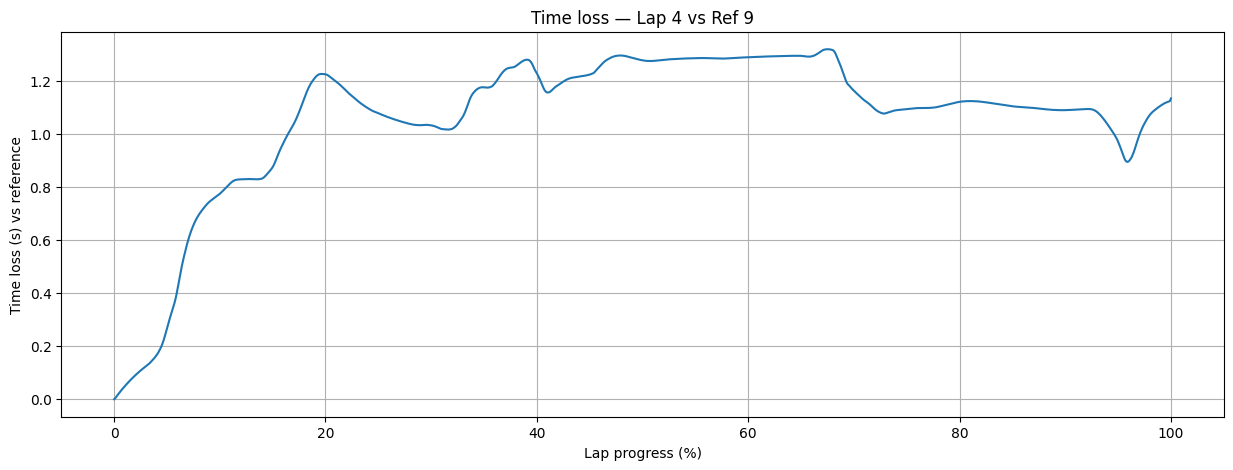

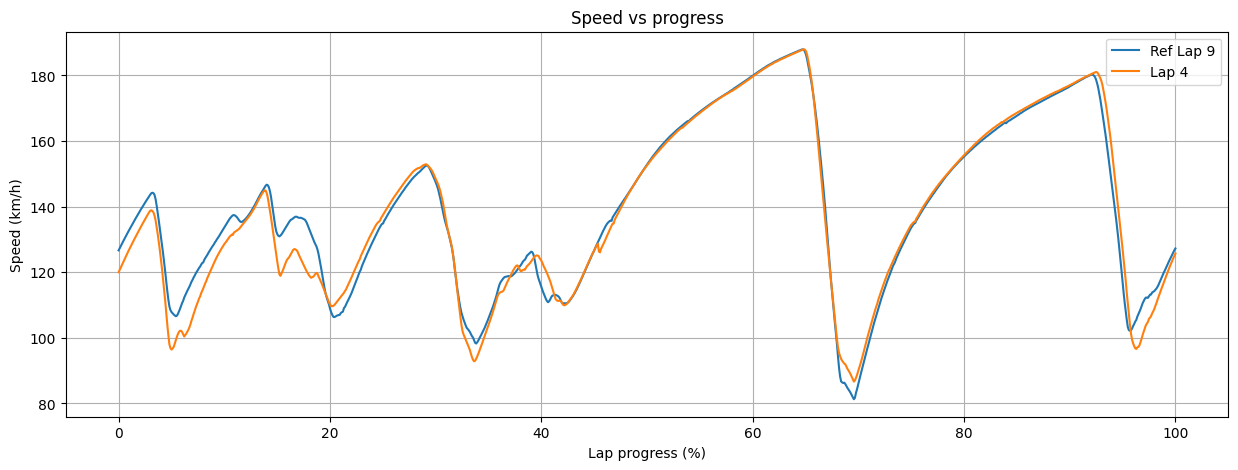

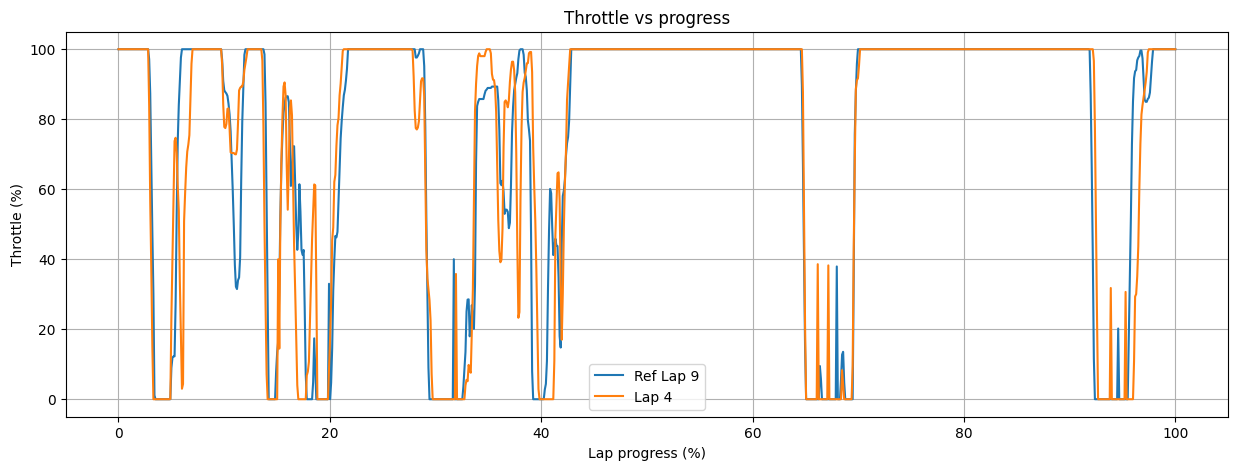

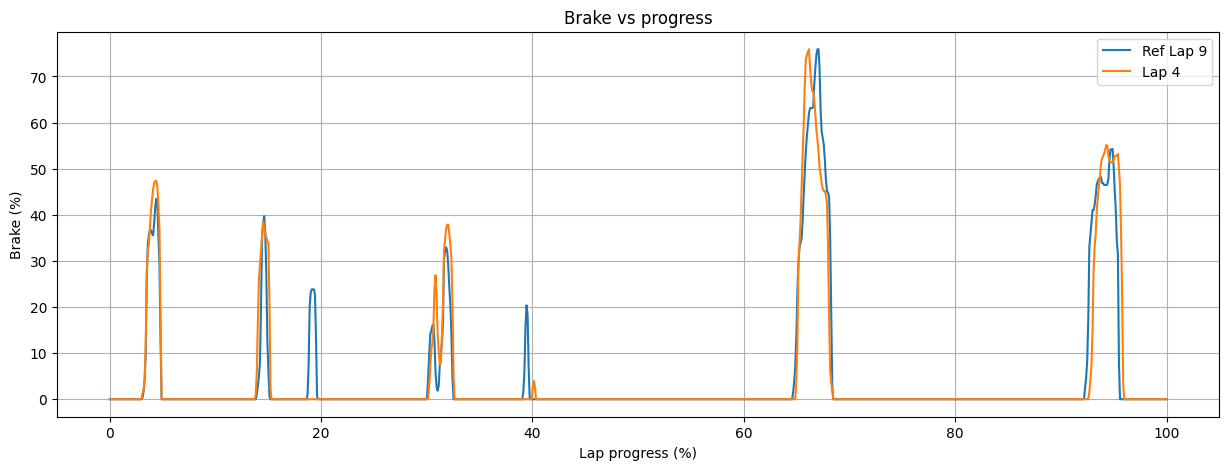

In [26]:

grid = np.linspace(0.0, 1.0, BASE_GRID_LEN)

g_ref = df[df["Lap"] == ref_lap]
g_tgt = df[df["Lap"] == target_lap]

ref_interp = align_lap_by_dist(g_ref, grid)
tgt_interp = align_lap_by_dist(g_tgt, grid)

# Time-loss curve (target vs reference)
time_loss = tgt_interp["t_rel"] - ref_interp["t_rel"]

plt.figure(figsize=(15, 5))
plt.plot(grid*100.0, time_loss)
plt.xlabel("Lap progress (%)")
plt.ylabel("Time loss (s) vs reference")
plt.title(f"Time loss — Lap {target_lap} vs Ref {ref_lap}")
plt.grid(True)
plt.show()

# Overlay speed, throttle, brake
def quick_plot(y1, y2, label, ylab):
    plt.figure(figsize=(15, 5))
    plt.plot(grid*100.0, y1, label=f"Ref Lap {ref_lap}")
    plt.plot(grid*100.0, y2, label=f"Lap {target_lap}")
    plt.xlabel("Lap progress (%)")
    plt.ylabel(ylab)
    plt.title(f"{label} vs progress")
    plt.legend()
    plt.grid(True)
    plt.show()

quick_plot(ref_interp["speed"],    tgt_interp["speed"],    "Speed",    "Speed (km/h)")
quick_plot(ref_interp["throttle"], tgt_interp["throttle"], "Throttle", "Throttle (%)")
quick_plot(ref_interp["brake"],    tgt_interp["brake"],    "Brake",    "Brake (%)")



## 6. Sectorization and per-sector analysis

In the Charlotte track, we split the lap into **4 equal-length sectors** and compute per-sector **time, deltas, and simple signal differences**.


In [27]:

def sector_slices(n_points: int, n_sectors: int) -> List[slice]:
    edges = np.linspace(0, n_points - 1, n_sectors + 1).astype(int)
    out = []
    for i in range(n_sectors):
        a, b = edges[i], edges[i+1]
        if b <= a: b = a + 1
        out.append(slice(a, b + 1))
    return out

def sector_analysis(ref_interp: Dict[str, np.ndarray],
                    tgt_interp: Dict[str, np.ndarray],
                    n_sectors: int) -> pd.DataFrame:
    n = len(ref_interp["t_rel"])
    slices = sector_slices(n, n_sectors)
    rows = []
    for i, sl_ in enumerate(slices, start=1):
        a, b = sl_.start, sl_.stop - 1
        ref_sec_time = float(ref_interp["t_rel"][b] - ref_interp["t_rel"][a])
        tgt_sec_time = float(tgt_interp["t_rel"][b] - tgt_interp["t_rel"][a])
        sl = slice(a, b + 1)
        rows.append({
            "Sector": i,
            "Start_%": round(100 * a / (n-1), 1),
            "End_%":   round(100 * b / (n-1), 1),
            "RefTime_s": ref_sec_time,
            "TargetTime_s": tgt_sec_time,
            "DeltaTime_s": float(tgt_sec_time - ref_sec_time),
            "MeanSpeedDiff_kph": float(np.nanmean(tgt_interp["speed"][sl] - ref_interp["speed"][sl])),
            "MeanThrottleDiff_pct": float(np.nanmean(tgt_interp["throttle"][sl] - ref_interp["throttle"][sl])),
            "MeanBrakeDiff_pct": float(np.nanmean(tgt_interp["brake"][sl] - ref_interp["brake"][sl])),
        })
    return pd.DataFrame(rows)

sectors = sector_analysis(ref_interp, tgt_interp, n_sectors=N_SECTORS)
sectors


,Sector,Start_%,End_%,RefTime_s,TargetTime_s,DeltaTime_s,MeanSpeedDiff_kph,MeanThrottleDiff_pct,MeanBrakeDiff_pct
0,1,0.0,24.9,25.282356,26.361385,1.079029,-4.693088,-1.382918,0.228615
1,2,24.9,49.9,25.940012,26.138315,0.198302,-0.134288,0.492010,0.298705
2,3,49.9,75.0,22.732079,22.547775,-0.184304,0.546644,0.172643,-0.464969
3,4,75.0,100.0,21.878886,21.919193,0.040306,0.601855,-0.937786,0.235966



## 7. Feature engineering per sector (all valid laps) + robust reference

We compute compact sector-level features for **every valid lap**, and we build a **robust sector reference** as the **median** of the top K% fastest laps.
